# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.2/481.2 kB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.3 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.30.1 which is incompatible.
diffusers 0.38.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.30.1 which is incompatible.
transformers 5.12.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.30.1 which is incompatible.
google-adk 1.29.0 requires requests<3.0.0,>=2.32.4, but you have

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
# Load the dataset from a CSV file into a Pandas DataFrame
superkart_data = pd.read_csv("/content/drive/My Drive/Colab Notebooks/SuperKart.csv",low_memory=False)

In [20]:
# Create a copy of the dataframe
dataset = superkart_data.copy()

# **Data Overview**

In [7]:
# Display the first five rows of the dataset
dataset.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [8]:
# checking shape of the data
print(f"There are {dataset.shape[0]} rows and {dataset.shape[1]} columns.")

There are 8763 rows and 12 columns.


In [9]:
# Display the column names of the dataset
dataset.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

In [10]:
# checking column datatypes and number of non-null values
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


## Observations

- Product_Weight, Product_Allocated_Area, Product_MRP,Store_Establishment_Year, Product_Store_Sales_Total  are numerical type and all other are variables are categorical.              

In [10]:
# checking for duplicate values
dataset.duplicated().sum()

np.int64(0)

- There are no duplicate values in the data.

In [11]:
# checking for missing values
dataset.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


- There are no missing values in the data.

In [15]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


- Product_Weight : Most of the data is clustering around 11 to 14.
- Product Allocated Are : Some products have been allocated very less space of 0.004 and some has given more space 0.298. As most of the product lies within 0.096 so most products occupy very small areas, but a few take up much larger space.
- Product MRP : Prices are spread widely. Mean and meidan around 147 are very near hence symmetrical distribution.
- Store_Establishment_Year : stores were established from 1998 to 2009.
- Product_Store_Sales_Total : Some store products has very less contributation where as some has huge contribution. This shows wide variation and outliers in data.

In [11]:
dataset.describe(include=['object']).T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


- Product_Id : It is unique ID value.
- Product_Sugar_Content - We have 4 unique value and Low Sugar tops the most more than 50%.
- Product_Type : 16 categories, with Fruits and Vegetables most frequent (1,249 entries).
- Store_Id : 4 unique stores, with OUT004 accounting for more than half the records (4,676).
- Store_Size : Most of the product sales can be from Medium store as per the data.
- Store_Location_City_Type : 3 unique location with most frquent sales belongs to Tier 2
- Store_Type : 4 unique with Supermarket Type2 as most frequent.
- The data shows most of the sales are from mid size City as interpreted from Tier 2 Medium store size.

# **Data Preprocessing**

In [16]:
dataset['Store_Establishment_Year'].value_counts()

,count
Store_Establishment_Year,
2009,4676
1987,1586
1999,1349
1998,1152


In [21]:
# Converting the Store stabishment year into datetime
dataset['Store_Establishment_Year'] = pd.to_datetime(dataset['Store_Establishment_Year'], format='%Y')

In [23]:
# Calculate store age
current_year = pd.Timestamp.now().year
dataset['Store_Age'] = current_year - dataset['Store_Establishment_Year'].dt.year

In [24]:
dataset['Store_Age'].value_counts()

,count
Store_Age,
17,4676
39,1586
27,1349
28,1152


In [12]:
dataset['Product_Sugar_Content'].value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2251
No Sugar,1519
reg,108


In [25]:
# Correcting reg to Regular
dataset['Product_Sugar_Content'].replace('reg', 'Regular', inplace=True)

In [14]:
dataset['Product_Sugar_Content'].value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


In [21]:
dataset['Product_Type'].value_counts()

,count
Product_Type,
Fruits and Vegetables,1249
Snack Foods,1149
Frozen Foods,811
Dairy,796
Household,740
Baking Goods,716
Canned,677
Health and Hygiene,628
Meat,618


In [22]:
dataset['Store_Id'].value_counts()

,count
Store_Id,
OUT004,4676
OUT001,1586
OUT003,1349
OUT002,1152


In [23]:
dataset['Store_Size'].value_counts()

,count
Store_Size,
Medium,6025
High,1586
Small,1152


In [24]:
dataset['Store_Location_City_Type'].value_counts()

,count
Store_Location_City_Type,
Tier 2,6262
Tier 1,1349
Tier 3,1152


In [25]:
dataset['Store_Type'].value_counts()

,count
Store_Type,
Supermarket Type2,4676
Supermarket Type1,1586
Departmental Store,1349
Food Mart,1152


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [28]:
dataset.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

In [26]:
df=dataset.copy()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Product_Id                 8763 non-null   object        
 1   Product_Weight             8763 non-null   float64       
 2   Product_Sugar_Content      8763 non-null   object        
 3   Product_Allocated_Area     8763 non-null   float64       
 4   Product_Type               8763 non-null   object        
 5   Product_MRP                8763 non-null   float64       
 6   Store_Id                   8763 non-null   object        
 7   Store_Establishment_Year   8763 non-null   datetime64[ns]
 8   Store_Size                 8763 non-null   object        
 9   Store_Location_City_Type   8763 non-null   object        
 10  Store_Type                 8763 non-null   object        
 11  Product_Store_Sales_Total  8763 non-null   float64       
 12  Store_

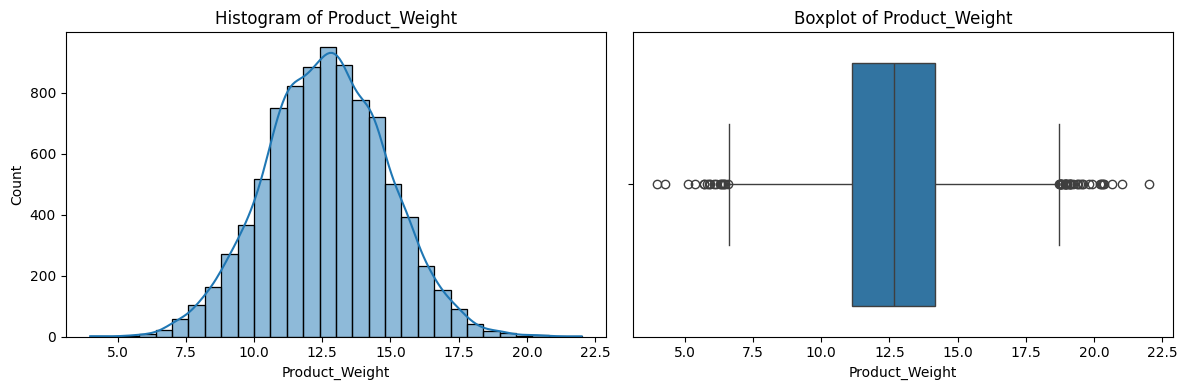

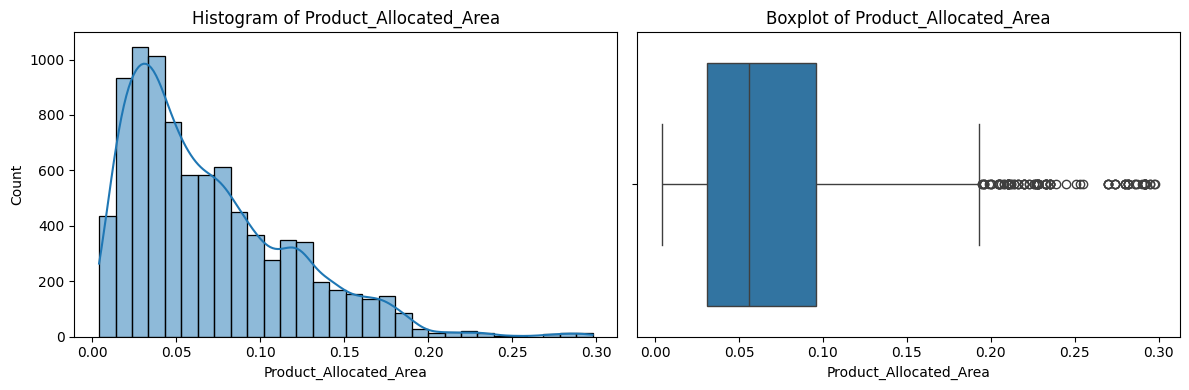

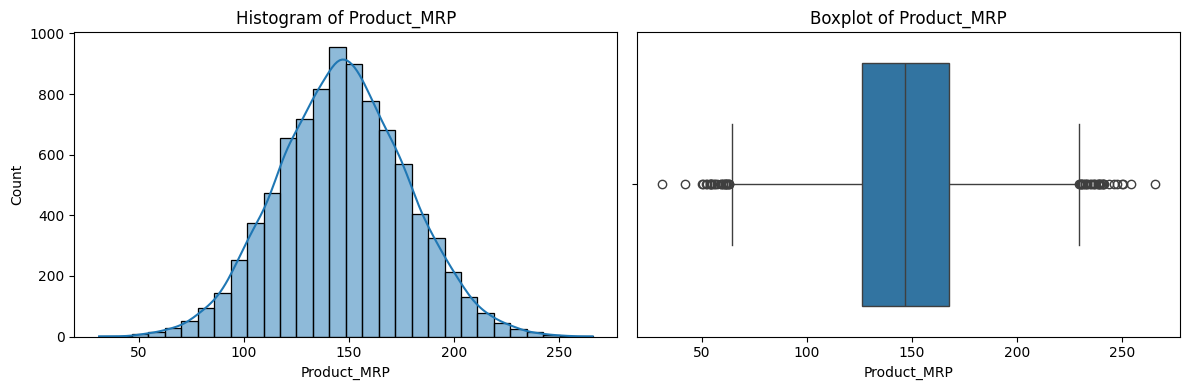

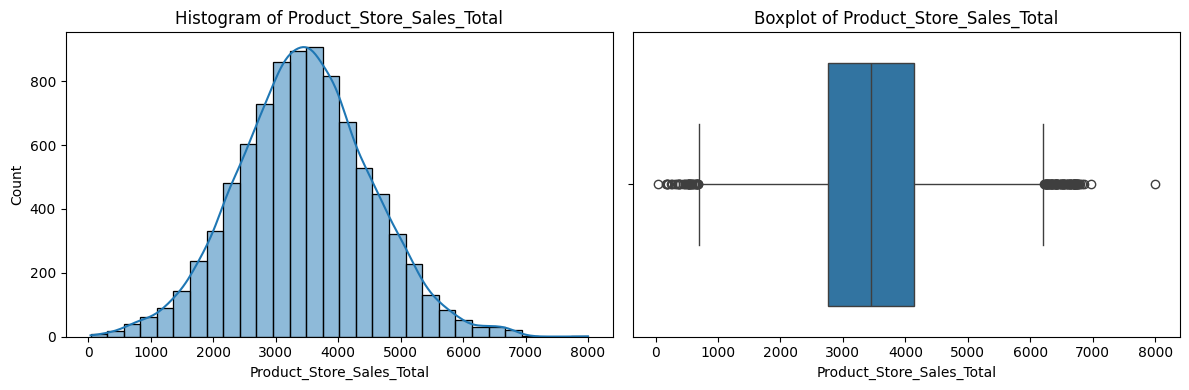

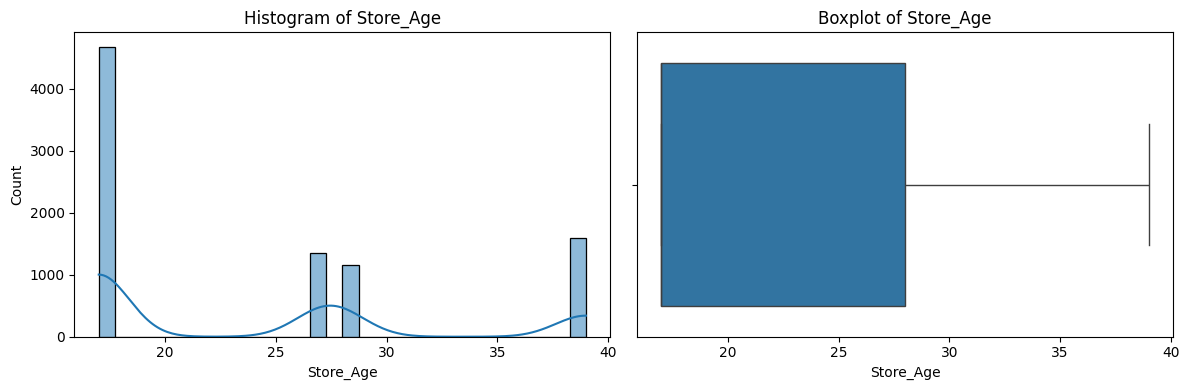

In [30]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64','int32']).columns

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(df[col], kde=True, bins=30, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

- Product_Weight : Its almost symmetrical with some outliers at both lower and higher side. Some products eg. Snack Foods chips, biscuits, packaged snacks can be light and some products eg. Fruits and Vegetables like potato, Household items  like detergent can be heavy.
- Product_Allocated_Area : It is right skewed, most of the product occupy less area range between 0.01 to 0.10 whereas some products take area upto 0.30
- Product_MRP : The distribution of Product_MRP is approximately normal (bell‑shaped) along with some outliers at low and high side indicating that some product are very less in price and some are high which is obvious for a retails store with small and premium products.
- Store_Establishment_Year/Store Age : The majority of the sale is from the store establish in 2009 which is the latest, indicating modern infrastructure and potentially higher sales efficiency. Older store might retain regular customer but may lack to attract new customer which might go to other outlets in Mall or shopping complex.
- Product Sales Total (Target Variable) :  It has a symmetrical normal distribution with median approx. at 3500 and majority of order value amounts between range of 2800 to 4200.  

## Bivariate Analysis

# **Data Preprocessing**

# **Model Building**

## Define functions for Model Evaluation

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

# **Model Performance Improvement - Hyperparameter Tuning**

# **Model Performance Comparison, Final Model Selection, and Serialization**

# **Deployment - Backend**

## Flask Web Framework


## Dependencies File

## Dockerfile

## Setting up a Hugging Face Docker Space for the Backend

## Uploading Files to Hugging Face Space (Docker Space)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

## Dependencies File

## DockerFile

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

## Uploading Files to Hugging Face Space (Streamlit Space)

# **Actionable Insights and Business Recommendations**

-

-